In [1]:

# Import libraries
import pandas as pd
import numpy as np

# Load dataset
file_path = "drug_consumption.data"
df = pd.read_csv(file_path, header=None)

print("Shape:", df.shape)
df.head()


Shape: (1885, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [2]:

# Add proper column names (UCI Drug Consumption dataset standard)
col_names = [
    "ID","Age","Gender","Education","Country","Ethnicity",
    "Nscore","Escore","Oscore","Ascore","Cscore","Impulsive","SS",
    "Alcohol","Amphet","Amyl","Benzos","Caff","Cannabis","Choc","Coke","Crack",
    "Ecstasy","Heroin","Ketamine","Legalh","LSD","Meth","Mushrooms","Nicotine","Semer","VSA"
]
df.columns = col_names

print("Columns assigned:", len(df.columns))
df.head()


Columns assigned: 32


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [3]:

# Basic cleaning checks (missing + duplicates)
print("Missing values per column (should be 0):")
print(df.isnull().sum().sum())

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# If duplicates exist, remove them (safe step)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)


Missing values per column (should be 0):
0
Duplicate rows: 0
Shape after duplicate removal: (1885, 32)


In [4]:

# Convert drug usage labels (CL0..CL6) to ordered numeric classes 0..6
drug_cols = col_names[13:]  # all drug columns

class_map = {f"CL{i}": i for i in range(7)}

for c in drug_cols:
    df[c] = df[c].map(class_map).astype(int)

print("Drug columns converted to numeric classes (0..6).")
df[drug_cols].head()


Drug columns converted to numeric classes (0..6).


,Alcohol,Amphet,Amyl,Benzos,Caff,Cannabis,Choc,Coke,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,5,2,0,2,6,0,5,0,0,0,0,0,0,0,0,0,2,0,0
1,5,2,2,0,6,4,6,3,0,4,0,2,0,2,3,0,4,0,0
2,6,0,0,0,6,3,4,0,0,0,0,0,0,0,0,1,0,0,0
3,4,0,0,3,5,2,4,2,0,0,0,2,0,0,0,0,2,0,0
4,4,1,1,0,6,3,6,0,0,1,0,0,1,0,0,2,2,0,0


In [5]:
# Cell 6
# Create binary drug-use flags (simple version)
# Here: 0 = Never used (CL0), 1 = Used at least once (CL1..CL6)
for c in drug_cols:
    df[c + "_binary"] = (df[c] >= 1).astype(int)

print("Binary drug-use columns created.")
df[[drug_cols[0], drug_cols[0] + "_binary"]].head()


Binary drug-use columns created.


,Alcohol,Alcohol_binary
0,5,1
1,5,1
2,6,1
3,4,1
4,4,1


In [6]:
# Cell 7
# Final cleaning step: remove duplicates and null values

print("Before cleaning:")
print("Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Remove null values (extra safety, dataset already clean)
df = df.dropna()

# Reset index
df = df.reset_index(drop=True)

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())


Before cleaning:
Shape: (1885, 51)
Total Missing Values: 0
Duplicate Rows: 0

After cleaning:
Shape: (1885, 51)
Total Missing Values: 0
Duplicate Rows: 0


In [7]:
# -----------------------------
# Dataset structure information
# -----------------------------
print("Dataset shape (rows, columns):", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nFirst 5 rows:")
df.head()

Dataset shape (rows, columns): (1885, 51)

Column data types:
ID                    int64
Age                 float64
Gender              float64
Education           float64
Country             float64
Ethnicity           float64
Nscore              float64
Escore              float64
Oscore              float64
Ascore              float64
Cscore              float64
Impulsive           float64
SS                  float64
Alcohol               int64
Amphet                int64
Amyl                  int64
Benzos                int64
Caff                  int64
Cannabis              int64
Choc                  int64
Coke                  int64
Crack                 int64
Ecstasy               int64
Heroin                int64
Ketamine              int64
Legalh                int64
LSD                   int64
Meth                  int64
Mushrooms             int64
Nicotine              int64
Semer                 int64
VSA                   int64
Alcohol_binary        int64
Amphet_binary 

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy_binary,Heroin_binary,Ketamine_binary,Legalh_binary,LSD_binary,Meth_binary,Mushrooms_binary,Nicotine_binary,Semer_binary,VSA_binary
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,0,0,0,0,0,0,0,1,0,0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,1,0,1,0,1,1,0,1,0,0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,0,0,0,0,0,0,1,0,0,0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,0,0,1,0,0,0,0,1,0,0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,1,0,0,1,0,0,1,1,0,0


In [8]:
# -----------------------------
# Descriptive statistics
# -----------------------------
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
ID,1885.0,945.294960,545.167641,1.00000,474.00000,946.00000,1417.00000,1888.00000
Age,1885.0,0.034610,0.878360,-0.95197,-0.95197,-0.07854,0.49788,2.59171
Gender,1885.0,-0.000256,0.482588,-0.48246,-0.48246,-0.48246,0.48246,0.48246
Education,1885.0,-0.003806,0.950078,-2.43591,-0.61113,-0.05921,0.45468,1.98437
Country,1885.0,0.355542,0.700335,-0.57009,-0.57009,0.96082,0.96082,0.96082
Ethnicity,1885.0,-0.309577,0.166226,-1.10702,-0.31685,-0.31685,-0.31685,1.90725
Nscore,1885.0,0.000047,0.998106,-3.46436,-0.67825,0.04257,0.62967,3.27393
Escore,1885.0,-0.000163,0.997448,-3.27393,-0.69509,0.00332,0.63779,3.27393
Oscore,1885.0,-0.000534,0.996229,-3.27393,-0.71727,-0.01928,0.72330,2.90161
Ascore,1885.0,-0.000245,0.997440,-3.46436,-0.60633,-0.01729,0.76096,3.46436


Class counts:
Cannabis_binary
1    1472
0     413
Name: count, dtype: int64


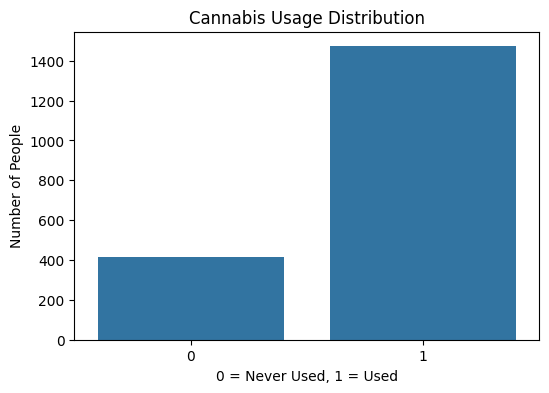

In [9]:
# -----------------------------
# Target variable distribution
# -----------------------------
target = "Cannabis_binary"

print("Class counts:")
print(df[target].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df[target])
plt.title("Cannabis Usage Distribution")
plt.xlabel("0 = Never Used, 1 = Used")
plt.ylabel("Number of People")
plt.show()

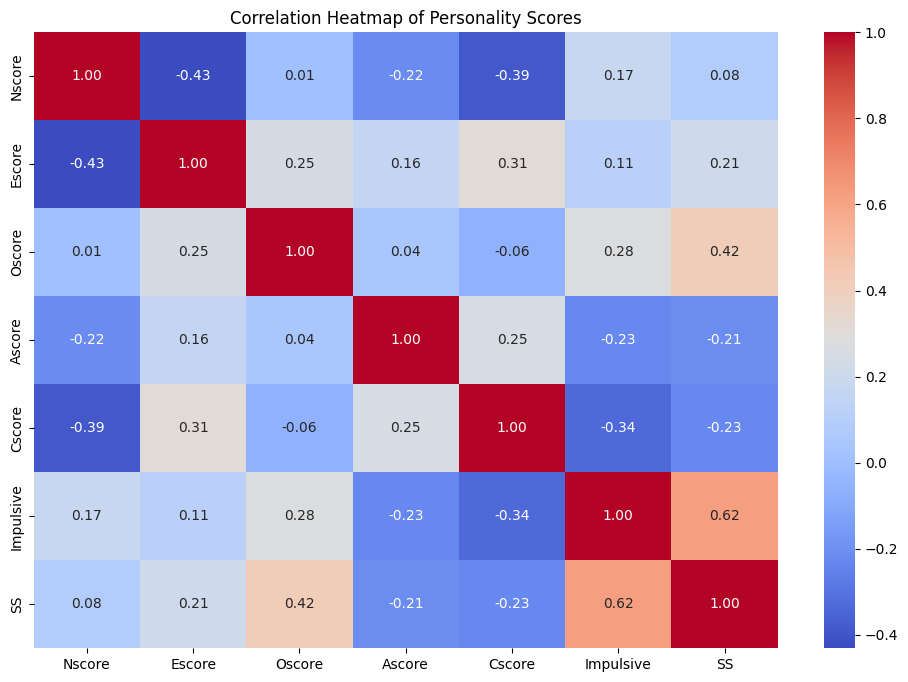

In [10]:
# -----------------------------
# Correlation heatmap
# -----------------------------
plt.figure(figsize=(12,8))

corr_cols = ["Nscore","Escore","Oscore","Ascore","Cscore","Impulsive","SS"]
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Personality Scores")
plt.show()

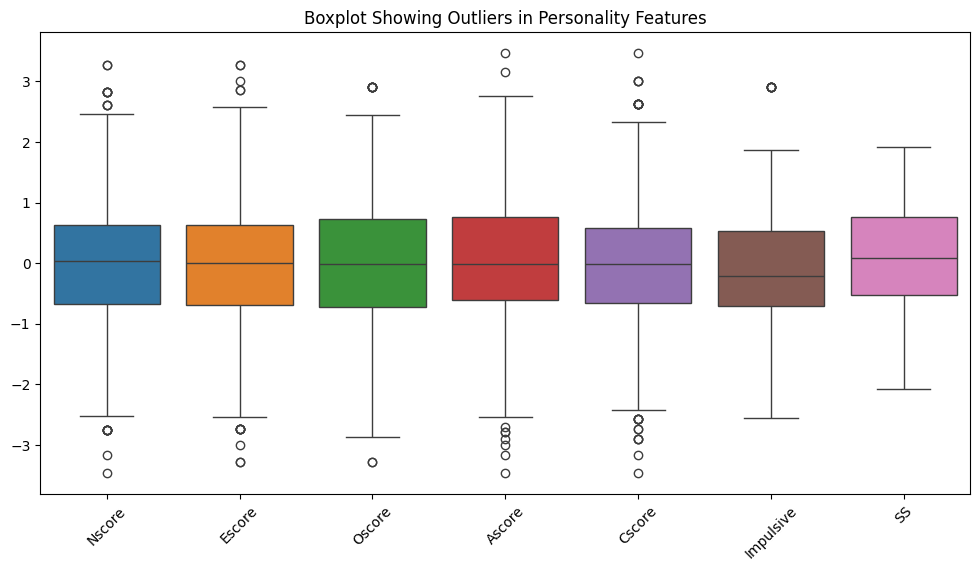

In [11]:
# -----------------------------
# Outlier detection using boxplot
# -----------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[corr_cols])
plt.xticks(rotation=45)
plt.title("Boxplot Showing Outliers in Personality Features")
plt.show()

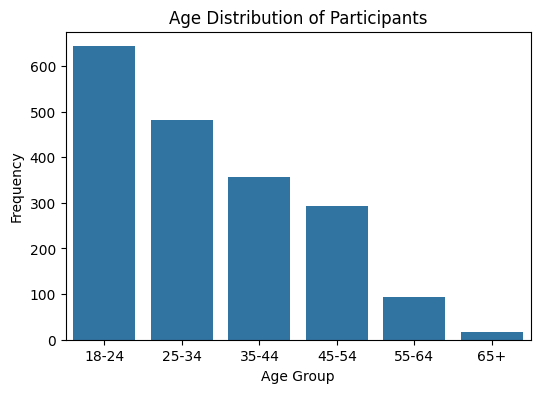

In [12]:
age_mapping = {
    -0.95197: "18-24",
    -0.07854: "25-34",
    0.49788: "35-44",
    1.09449: "45-54",
    1.82213: "55-64",
    2.59171: "65+"
}

df["Age_actual"] = df["Age"].map(age_mapping)
plt.figure(figsize=(6,4))
sns.countplot(x="Age_actual", data=df, order=[
    "18-24","25-34","35-44","45-54","55-64","65+"
])

plt.title("Age Distribution of Participants")
plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.show()

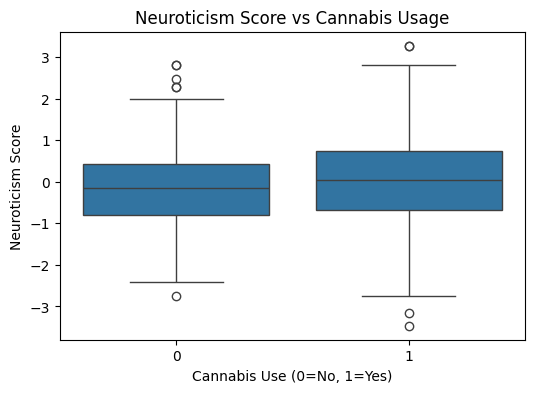

In [13]:
# -----------------------------
# Neuroticism vs Cannabis usage
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Cannabis_binary"], y=df["Nscore"])
plt.title("Neuroticism Score vs Cannabis Usage")
plt.xlabel("Cannabis Use (0=No, 1=Yes)")
plt.ylabel("Neuroticism Score")
plt.show()

In [14]:
# -----------------------------
# Label Encoding categorical features
# -----------------------------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ["Gender","Education","Country","Ethnicity"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded.")
df[cat_cols].head()

Categorical columns encoded.


,Gender,Education,Country,Ethnicity
0,1,5,6,5
1,0,8,6,2
2,0,5,6,2
3,1,7,6,2
4,1,8,6,2


In [15]:
# -----------------------------
# Select target variable
# -----------------------------
target = "Cannabis_binary"

# Input features
feature_cols = [
    "Age","Gender","Education","Country","Ethnicity",
    "Nscore","Escore","Oscore","Ascore","Cscore","Impulsive","SS"
]

X = df[feature_cols]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:\n", y.value_counts())

Feature matrix shape: (1885, 12)
Target shape: (1885,)

Target distribution:
 Cannabis_binary
1    1472
0     413
Name: count, dtype: int64


In [16]:
# -----------------------------
# Train Test Split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1508, 12)
Testing set: (377, 12)


In [19]:
# -----------------------------
# Standard Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [20]:
# -----------------------------
# SMOTE - Oversampling
# -----------------------------
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Cannabis_binary
1    1178
0     330
Name: count, dtype: int64
After SMOTE: Cannabis_binary
0    1178
1    1178
Name: count, dtype: int64


In [21]:
# ----------------------------------------
# RANDOM FOREST MODEL
# ----------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train model
rf_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix values
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Random Forest Accuracy: 0.8063660477453581

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.54      0.55        83
           1       0.87      0.88      0.88       294

    accuracy                           0.81       377
   macro avg       0.72      0.71      0.71       377
weighted avg       0.80      0.81      0.81       377

Confusion Matrix:
 [[ 45  38]
 [ 35 259]]


In [22]:
# ----------------------------------------
# XGBOOST MODEL
# ----------------------------------------
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix values
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm_xgb)

XGBoost Accuracy: 0.8169761273209549

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.55      0.57        83
           1       0.88      0.89      0.88       294

    accuracy                           0.82       377
   macro avg       0.73      0.72      0.73       377
weighted avg       0.81      0.82      0.81       377

Confusion Matrix:
 [[ 46  37]
 [ 32 262]]


In [23]:
# ----------------------------------------
# SVM MODEL
# ----------------------------------------
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Train
svm_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix values
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

SVM Accuracy: 0.7771883289124668

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.78      0.61        83
           1       0.93      0.78      0.84       294

    accuracy                           0.78       377
   macro avg       0.71      0.78      0.73       377
weighted avg       0.83      0.78      0.79       377

Confusion Matrix:
 [[ 65  18]
 [ 66 228]]


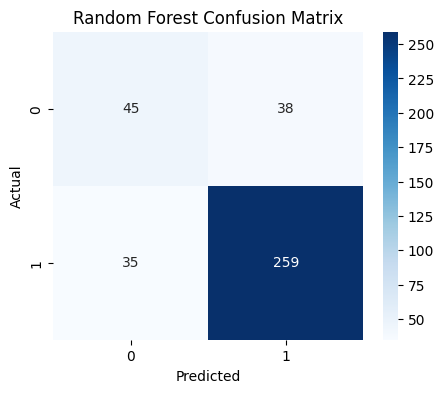

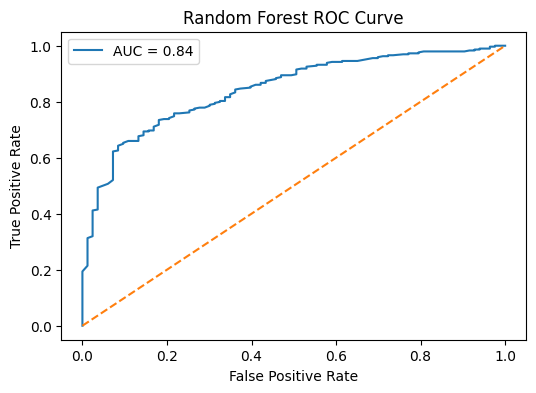

In [24]:
# ----------------------------------------
# Random Forest Confusion Matrix + ROC
# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Confusion Matrix Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

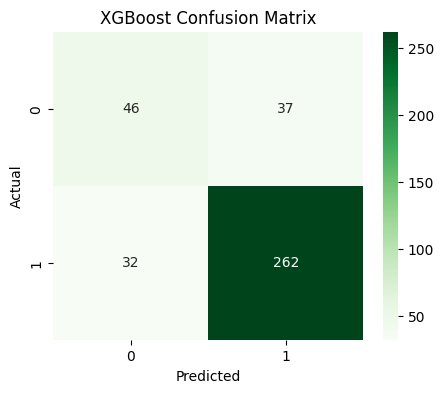

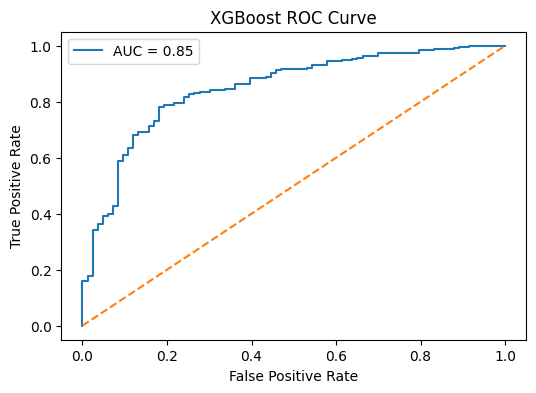

In [25]:
# ----------------------------------------
# XGBoost Confusion Matrix + ROC
# ----------------------------------------
# Confusion matrix plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_xgb:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

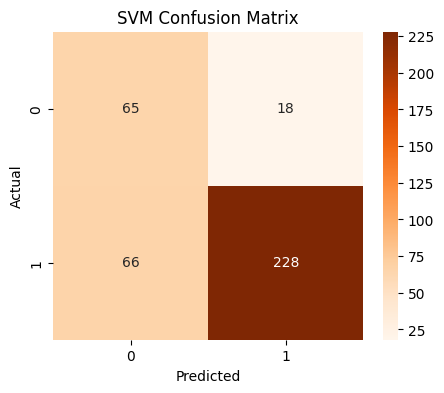

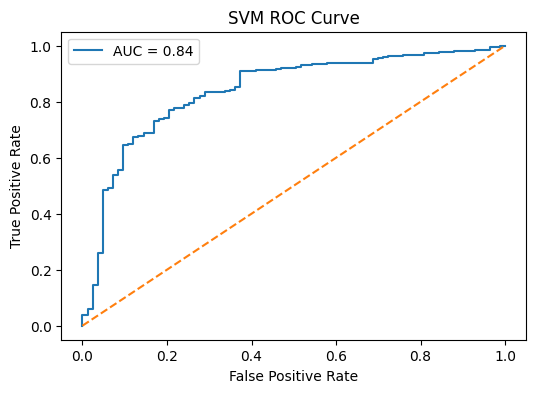

In [26]:
# ----------------------------------------
# SVM Confusion Matrix + ROC
# ----------------------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_svm:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [27]:
# ----------------------------------------
# RandomizedSearchCV - Random Forest
# ----------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

rf_param_dist = {
    "n_estimators": [200, 300, 400, 500, 700],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=30,              # number of random combinations
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_smote, y_train_smote)

print("Best Random Forest Parameters:", rf_random.best_params_)
print("Best Random Forest CV Score (F1):", rf_random.best_score_)

Best Random Forest Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}
Best Random Forest CV Score (F1): 0.885731392251903


In [28]:
# ----------------------------------------
# Evaluate Tuned Random Forest
# ----------------------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_rf = rf_random.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
print("Confusion Matrix:\n", cm_best_rf)

Tuned Random Forest Accuracy: 0.7931034482758621

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.49      0.51        83
           1       0.86      0.88      0.87       294

    accuracy                           0.79       377
   macro avg       0.70      0.69      0.69       377
weighted avg       0.79      0.79      0.79       377

Confusion Matrix:
 [[ 41  42]
 [ 36 258]]


In [29]:
# ----------------------------------------
# RandomizedSearchCV - XGBoost
# ----------------------------------------
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_lambda": [1, 1.5, 2, 3]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_smote, y_train_smote)

print("Best XGBoost Parameters:", xgb_random.best_params_)
print("Best XGBoost CV Score (F1):", xgb_random.best_score_)

Best XGBoost Parameters: {'subsample': 0.7, 'reg_lambda': 3, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best XGBoost CV Score (F1): 0.8729758835288823


In [30]:
# ----------------------------------------
# Evaluate Tuned XGBoost
# ----------------------------------------
best_xgb = xgb_random.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_xgb))

cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
print("Confusion Matrix:\n", cm_best_xgb)

Tuned XGBoost Accuracy: 0.8196286472148541

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.52      0.56        83
           1       0.87      0.90      0.89       294

    accuracy                           0.82       377
   macro avg       0.74      0.71      0.72       377
weighted avg       0.81      0.82      0.81       377

Confusion Matrix:
 [[ 43  40]
 [ 28 266]]


In [31]:
# ----------------------------------------
# RandomizedSearchCV - SVM
# ----------------------------------------
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)

svm_param_dist = {
    "C": [0.1, 0.5, 1, 5, 10, 20],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "degree": [2, 3, 4]   # only used for 'poly' kernel (safe to include)
}

svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_dist,
    n_iter=25,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

svm_random.fit(X_train_smote, y_train_smote)

print("Best SVM Parameters:", svm_random.best_params_)
print("Best SVM CV Score (F1):", svm_random.best_score_)

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'degree': 4, 'C': 20}
Best SVM CV Score (F1): 0.8629624288971574


In [32]:
# ----------------------------------------
# Evaluate Tuned SVM
# ----------------------------------------
best_svm = svm_random.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_scaled)

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_best_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_svm))

cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)
print("Confusion Matrix:\n", cm_best_svm)

Tuned SVM Accuracy: 0.7904509283819628

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.58      0.55        83
           1       0.88      0.85      0.86       294

    accuracy                           0.79       377
   macro avg       0.70      0.71      0.71       377
weighted avg       0.80      0.79      0.79       377

Confusion Matrix:
 [[ 48  35]
 [ 44 250]]
